In [57]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/raw/diabetic_data.csv")
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [58]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

## Hipótesis clínicas — qué predice readmisión en < 30 días

### Variables que creo que importan y por qué

1. number_inpatient — historial de ingresos previos. 
   Mejor predictor individual del dataset.
2. number_emergency — urgencias previas. 
   Patrón de uso intensivo del sistema sanitario.
3. time_in_hospital — días ingresado. 
   Proxy de gravedad del episodio actual.
4. num_medications — número de medicamentos. 
   Proxy de complejidad clínica y comorbilidades.
5. insulin + change — cambios en medicación durante ingreso. 
   Indica descompensación glucémica.
6. discharge_disposition_id — destino al alta. 
   Estado funcional del paciente al salir.
7. age — edad en rangos. 
   Mayor edad, mayor fragilidad.
8. diag_1/2/3 — diagnósticos ICD-9. 
   Tipo y gravedad de la enfermedad.

### Variables que NO importan

1. weight — 97% nulls. Eliminamos directamente.
2. payer_code — demasiados nulls, valor clínico bajo.
3. encounter_id — identificador técnico, no clínico.

In [59]:
# Nulls reales que tenemos ahora:
df.replace('?', np.nan, inplace=True)

nulls = df.isnull().sum()
nulls_pct=(nulls / len(df) * 100).round(1)

null_df = pd.DataFrame({
    'nulls': nulls,
    'percentage': nulls_pct
}).query('nulls > 0').sort_values('percentage', ascending=False)

print(null_df)


                   nulls  percentage
weight             98569        96.9
max_glu_serum      96420        94.7
A1Cresult          84748        83.3
medical_specialty  49949        49.1
payer_code         40256        39.6
race                2273         2.2
diag_3              1423         1.4
diag_2               358         0.4
diag_1                21         0.0


In [60]:
# Decisiones sobre columnas con nulls — versión limpia

# Eliminamos columnas con demasiados nulls o poco valor clínico
cols_to_drop = ['weight', 'max_glu_serum', 'A1Cresult', 
                'medical_specialty', 'payer_code']
df.drop(columns=cols_to_drop, inplace=True)

# Imputamos race con la moda
df['race'] = df['race'].fillna(df['race'].mode()[0])

# Imputamos diagnósticos con 'Unknown'
df['diag_1'] = df['diag_1'].fillna('Unknown')
df['diag_2'] = df['diag_2'].fillna('Unknown')
df['diag_3'] = df['diag_3'].fillna('Unknown')

# Verificamos que no quedan nulls
print("Nulls restantes:", df.isnull().sum().sum())
print(f"Shape actual: {df.shape}")

Nulls restantes: 0
Shape actual: (101766, 45)


Dead & Duplicated Patients

Asegurarnos de que cada paciente en el dataset aparece una sola vez, y que solo incluimos pacientes que realmente pudieron ser readmitidos.
Dos problemas distintos, dos soluciones.

In [61]:
# 1. Cuántos pacientes únicos vs encuentros
print(f"Total finds: {len(df)}")
print(f"Unique Patients: {df['patient_nbr'].nunique()}")
print(f"Duplicated patients: {len(df) - df['patient_nbr'].nunique()}")
print()

# 2. Filtrar pacientes fallecidos durante el ingreso
# discharge_disposition_id 11, 13, 14, 19, 20 = fallecido o en hospicio
ids_fallecidos = [11, 13, 14, 19, 20]
fallecidos = df[df['discharge_disposition_id'].isin(ids_fallecidos)]
print(f"Death patiens or in hospice: {len(fallecidos)}")

# Eliminamos — un paciente fallecido no puede ser readmitido
df = df[~df['discharge_disposition_id'].isin(ids_fallecidos)]
print(f"Shape after delete the dead patients: {df.shape}")
print()

# 3. Quedarnos con el primer encuentro de cada paciente
# Por qué: evitar data leakage — el mismo paciente en train y test
df = df.sort_values('encounter_id').drop_duplicates(
    subset='patient_nbr', keep='first'
)
print(f"Shape after delete the duplicated one: {df.shape}")

Total finds: 101766
Unique Patients: 71518
Duplicated patients: 30248

Death patiens or in hospice: 2423
Shape after delete the dead patients: (99343, 45)

Shape after delete the duplicated one: (69990, 45)


Por qué: antes de seguir con feature engineering necesitamos confirmar que el desbalance de clases sigue siendo manejable después de quitar 31,776 filas. Si el porcentaje de readmisiones <30 cambió mucho, ajusta nuestra estrategia de modelado

In [62]:
# Target tras limpieza
print(df['readmitted'].value_counts())
print()
print(df['readmitted'].value_counts(normalize=True).round(3))

readmitted
NO     41479
>30    22226
<30     6285
Name: count, dtype: int64

readmitted
NO     0.593
>30    0.318
<30    0.090
Name: proportion, dtype: float64


# Final EDA

El target es la columna que el modelo va a aprender a predecir. Sin target no hay machine learning supervisado — es literalmente lo que defines como "la respuesta correcta".

In [63]:
# Crear target binario
df['readmitted_30d'] = (df['readmitted'] == '<30').astype(int)

print(df['readmitted_30d'].value_counts())
print(df['readmitted_30d'].value_counts(normalize=True).round(3))

readmitted_30d
0    63705
1     6285
Name: count, dtype: int64
readmitted_30d
0    0.91
1    0.09
Name: proportion, dtype: float64


Por qué: comparamos la media de ingresos previos entre el grupo que SÍ fue readmitido (1) y el que NO (0). Si tu hipótesis es correcta, el grupo 1 debería tener una media notablemente más alta.

In [64]:
# number_inpatient vs readmisión
df.groupby('readmitted_30d')['number_inpatient'].mean()

readmitted_30d
0    0.157319
1    0.368337
Name: number_inpatient, dtype: float64

ingresos muy largos o muy cortos podrían indicar riesgo.

 no todas tus hipótesis se confirman igual de fuerte. time_in_hospital por sí sola es una señal débil. Probablemente no es un mal predictor, pero tampoco es de los fuertes — quizás importa más combinada con otras variables, algo que veremos en feature engineering.

In [67]:
df.groupby('readmitted_30d')['time_in_hospital'].mean()

readmitted_30d
0    4.221851
1    4.794749
Name: time_in_hospital, dtype: float64

Comparamos , para observar si el numero de medicamentos que se toma un paciente , tiene riesto:

Aproximadamente 1 medicamento más de media en el grupo readmitido. Señal débil-moderada


In [68]:
df.groupby('readmitted_30d')['num_medications'].mean()

readmitted_30d
0    15.571085
1    16.620366
Name: num_medications, dtype: float64

Si el destino al alta no influyera en la readmisión, los dos números serían parecidos — algo como 60% y 61%.
Pero hay una diferencia de 15 puntos. Eso significa que ir a casa directamente protege contra la readmisión rápida, y por el contrario — ir a una residencia o centro de rehabilitación (mira la fila 3 y 22, donde el porcentaje del grupo readmitido es mucho mayor) aumenta el riesgo.

In [69]:
df.groupby('readmitted_30d')['discharge_disposition_id'].value_counts(normalize=True).unstack().T

readmitted_30d,0,1
discharge_disposition_id,,
1,0.647406,0.489897
2,0.020862,0.033731
3,0.119457,0.187749
4,0.007629,0.008910
5,0.011381,0.029912
6,0.117730,0.125855
7,0.005808,0.006205
8,0.001036,0.001114
9,0.000110,0.000318


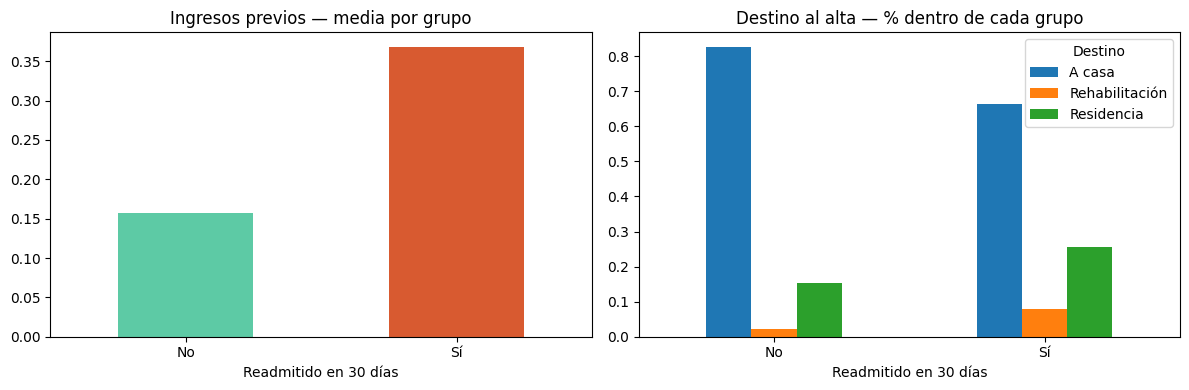

In [75]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico 1 — number_inpatient por grupo (igual que antes)
df.groupby('readmitted_30d')['number_inpatient'].mean().plot(
    kind='bar', ax=axes[0], color=['#5DCAA5', '#D85A30']
)
axes[0].set_title('Ingresos previos — media por grupo')
axes[0].set_xlabel('Readmitido en 30 días')
axes[0].set_xticklabels(['No', 'Sí'], rotation=0)

# Gráfico 2 — destino al alta, con nombres en vez de códigos
mapa_destinos = {1: 'A casa', 3: 'Residencia', 22: 'Rehabilitación'}

df_destinos = df[df['discharge_disposition_id'].isin([1, 3, 22])].copy()
df_destinos['destino'] = df_destinos['discharge_disposition_id'].map(mapa_destinos)

df_destinos.groupby('readmitted_30d')['destino'].value_counts(
    normalize=True
).unstack().plot(kind='bar', ax=axes[1])

axes[1].set_title('Destino al alta — % dentro de cada grupo')
axes[1].set_xlabel('Readmitido en 30 días')
axes[1].set_xticklabels(['No', 'Sí'], rotation=0)
axes[1].legend(title='Destino')

plt.tight_layout()
plt.savefig('../data/processed/eda_key_findings.png', dpi=150)
plt.show()

Cuanto menos autónomo sale el paciente del hospital — yendo a residencia o rehab en vez de a casa — mayor es la probabilidad de que vuelva en menos de 30 días.
Eso tiene sentido clínico: si el paciente necesita cuidados especializados al salir, es porque su estado de salud es más frágil, y la fragilidad predice recaída.

In [76]:
df.to_csv('../data/processed/diabetic_data_clean.csv', index=False)
print(f"Guardado: {df.shape}")

Guardado: (69990, 46)
